# Genipa Seed Digital Phenotyping: Analysis Pipeline

This notebook validates the processed dataset, removes morphometric outliers, performs PCA and MANOVA, trains Random Forest and Linear SVM classifiers, exports manuscript-ready figures, and displays the generated figures inline.

## 1. Imports and Configuration

In [1]:
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
import platform
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Image, Markdown, display
from sklearn.calibration import CalibratedClassifierCV
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    average_precision_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import LinearSVC
from statsmodels.multivariate.manova import MANOVA

warnings.filterwarnings("ignore", category=FutureWarning)


@dataclass(frozen=True)
class AnalysisConfig:
    random_state: int = 42
    root_length_threshold_mm: float = 35.0
    latex_line_width_pt: float = 394.35522
    tex_pt_per_inch: float = 72.27
    target: str = "germinated_root_gt_35mm"
    group: str = "lot"
    class_labels: tuple[str, str] = ("Non-germinated", "Germinated")
    morphometric_features: tuple[str, ...] = ("length_mm", "width_mm", "area_mm2", "perimeter_mm")
    engineered_features: tuple[str, ...] = (
        "length_width_ratio",
        "area_perimeter_ratio",
        "compactness",
        "seed_size_index",
    )

    @property
    def model_numeric_features(self) -> list[str]:
        return list(self.morphometric_features + self.engineered_features)

    @property
    def model_features(self) -> list[str]:
        return self.model_numeric_features + [self.group]

    @property
    def article_width_in(self) -> float:
        return self.latex_line_width_pt / self.tex_pt_per_inch


CONFIG = AnalysisConfig()

NOTEBOOK_DIR = Path.cwd()
ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "notebooks" else NOTEBOOK_DIR
DATA_PATH = ROOT / "data" / "processed" / "analytical_dataset.csv"
FIGURES_DIR = ROOT / "figures"
OUTPUTS_DIR = ROOT / "outputs"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)

FEATURE_LABELS = {
    "length_mm": "Length",
    "width_mm": "Width",
    "area_mm2": "Area",
    "perimeter_mm": "Perimeter",
}

# ROOT

## 2. Reproducible Plotting Helpers

In [2]:
def set_plot_style() -> None:
    sns.set_theme(
        context="paper",
        style="whitegrid",
        palette="colorblind",
        rc={
            "figure.dpi": 120,
            "savefig.dpi": 600,
            "savefig.format": "pdf",
            "axes.spines.top": False,
            "axes.spines.right": False,
            "axes.titleweight": "bold",
            "axes.labelsize": 10,
            "axes.titlesize": 10,
            "xtick.labelsize": 9,
            "ytick.labelsize": 9,
            "legend.fontsize": 8.5,
            "legend.title_fontsize": 9,
            "legend.frameon": False,
            "font.family": "serif",
            "font.serif": ["cmr10", "Computer Modern Roman", "CMU Serif", "DejaVu Serif"],
            "font.size": 10,
            "mathtext.fontset": "cm",
            "axes.formatter.use_mathtext": True,
            "pdf.fonttype": 42,
            "ps.fonttype": 42,
        },
    )


def article_figsize(height_ratio: float = 0.68, width_fraction: float = 1.0) -> tuple[float, float]:
    width = CONFIG.article_width_in * width_fraction
    return width, width * height_ratio


def style_axis(ax: plt.Axes) -> None:
    ax.grid(True, linestyle="--", linewidth=0.6, alpha=0.35)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


def save_figure(fig: plt.Figure, filename: str, png_dpi: int = 220) -> Path:
    fig.tight_layout(pad=0.35)
    pdf_path = (FIGURES_DIR / filename).with_suffix(".pdf")
    fig.savefig(pdf_path, format="pdf", dpi=600, facecolor="white")
    fig.savefig(pdf_path.with_suffix(".png"), format="png", dpi=png_dpi, facecolor="white")
    plt.close(fig)
    return pdf_path


def show_figure(filename: str, width: int = 900) -> None:
    pdf_path = (FIGURES_DIR / filename).with_suffix(".pdf")
    png_path = pdf_path.with_suffix(".png")
    if png_path.exists():
        display(Markdown(f"### `{pdf_path.name}`"))
        display(Image(filename=str(png_path), width=width))
    else:
        display(Markdown(f"**Figure preview not found:** `{png_path.name}`"))


def show_figure_series(filenames: list[str], width: int = 900) -> None:
    for filename in filenames:
        show_figure(filename, width=width)


set_plot_style()

## 3. Data Loading and Validation

In [3]:
def load_dataset(path: Path) -> pd.DataFrame:
    required_columns = [
        "seed_id",
        "lot",
        "length_mm",
        "width_mm",
        "area_mm2",
        "perimeter_mm",
        "root_length_mm",
        "germination_observed",
    ]
    df = pd.read_csv(path)
    missing = [column for column in required_columns if column not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    numeric_columns = [
        "lot",
        "length_mm",
        "width_mm",
        "area_mm2",
        "perimeter_mm",
        "root_length_mm",
        "germination_observed",
    ]
    for column in numeric_columns:
        df[column] = pd.to_numeric(df[column], errors="coerce")

    df[CONFIG.group] = df[CONFIG.group].astype("category")
    df[CONFIG.target] = (df["root_length_mm"] > CONFIG.root_length_threshold_mm).astype(int)
    return df


def summarize_dataset(df: pd.DataFrame) -> pd.DataFrame:
    return pd.DataFrame(
        {
            "rows": [len(df)],
            "lots": [df[CONFIG.group].nunique()],
            "missing_root_length": [df["root_length_mm"].isna().sum()],
            "non_germinated_target": [(df[CONFIG.target] == 0).sum()],
            "germinated_target": [(df[CONFIG.target] == 1).sum()],
        }
    )


df = load_dataset(DATA_PATH)
summarize_dataset(df)

,rows,lots,missing_root_length,non_germinated_target,germinated_target
0,15999,16,1,10004,5995


In [4]:
df.head()

,lot,image_id,seed_image,seed_id,grid_row,grid_column,calibration_px_per_cm,area_px,perimeter_px,width_px,...,area_mm2,perimeter_cm,perimeter_mm,width_cm,height_cm,length_mm,width_mm,germination_observed,root_length_mm,germinated_root_gt_35mm
0,1,L1G1,s_11.png,L1G1_s_11.png,1,1,183.5,2176.5,172.999,46,...,6.46378,0.942774,9.42774,0.250681,0.343324,2.50681,3.43324,1,70.9,1
1,1,L1G1,s_12.png,L1G1_s_12.png,1,2,183.5,2517.5,181.332,58,...,7.47648,0.988188,9.88188,0.316076,0.294278,3.16076,2.94278,1,42.9,1
2,1,L1G1,s_13.png,L1G1_s_13.png,1,3,183.5,2616.5,183.685,54,...,7.77049,1.001010,10.01010,0.294278,0.332425,2.94278,3.32425,1,34.3,0
3,1,L1G1,s_14.png,L1G1_s_14.png,1,4,183.5,2853.0,200.630,67,...,8.47285,1.093350,10.93350,0.365123,0.321526,3.65123,3.21526,1,61.9,1
4,1,L1G1,s_15.png,L1G1_s_15.png,1,5,183.5,3014.5,199.657,67,...,8.95248,1.088050,10.88050,0.365123,0.321526,3.65123,3.21526,1,40.9,1


## 4. Outlier Removal and Feature Engineering

The original notebook removes outliers using the 1.5 IQR rule for each morphometric feature. The same filtered table is used for PCA, MANOVA, and classification.

In [5]:
def remove_iqr_outliers(df: pd.DataFrame, features: tuple[str, ...]) -> pd.DataFrame:
    clean = df.copy()
    for feature in features:
        q1 = clean[feature].quantile(0.25)
        q3 = clean[feature].quantile(0.75)
        iqr = q3 - q1
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr
        clean = clean[clean[feature].between(lower_bound, upper_bound)]
    return clean


def add_engineered_features(df: pd.DataFrame) -> pd.DataFrame:
    engineered = df.copy()
    engineered["length_width_ratio"] = engineered["length_mm"] / engineered["width_mm"].replace(0, np.nan)
    engineered["area_perimeter_ratio"] = engineered["area_mm2"] / engineered["perimeter_mm"].replace(0, np.nan)
    engineered["compactness"] = 4 * np.pi * engineered["area_mm2"] / engineered["perimeter_mm"].pow(2).replace(0, np.nan)
    engineered["seed_size_index"] = engineered[["length_mm", "width_mm"]].mean(axis=1)
    return engineered.replace([np.inf, -np.inf], np.nan)


analysis_df = df.dropna(subset=list(CONFIG.morphometric_features) + [CONFIG.group, "root_length_mm"]).copy()
analysis_df = remove_iqr_outliers(analysis_df, CONFIG.morphometric_features)
analysis_df = add_engineered_features(analysis_df)
analysis_df = analysis_df.dropna(subset=CONFIG.model_features + [CONFIG.target]).copy()

pd.DataFrame({"original_rows": [len(df)], "analysis_rows": [len(analysis_df)]})

,original_rows,analysis_rows
0,15999,15513


## 5. Morphometric Distributions by Lot

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


### `self_contained_boxplot_length.pdf`

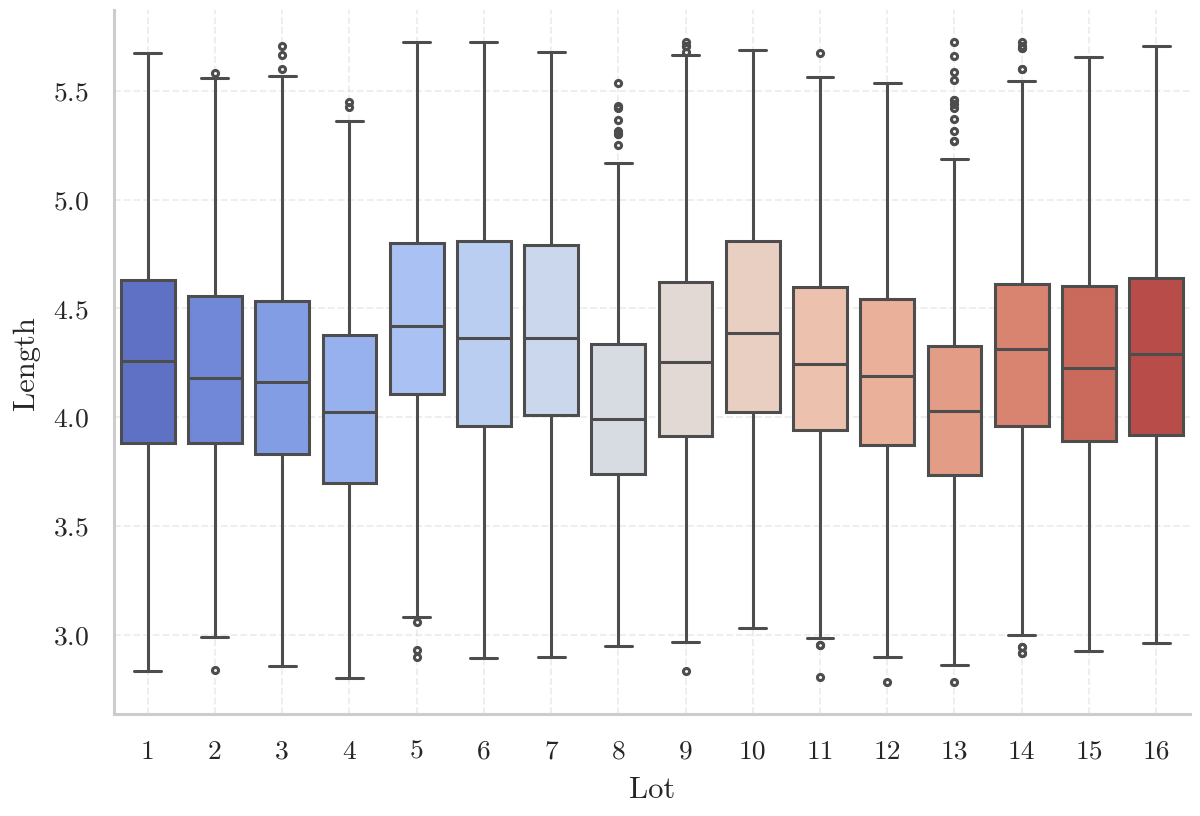

### `self_contained_boxplot_width.pdf`

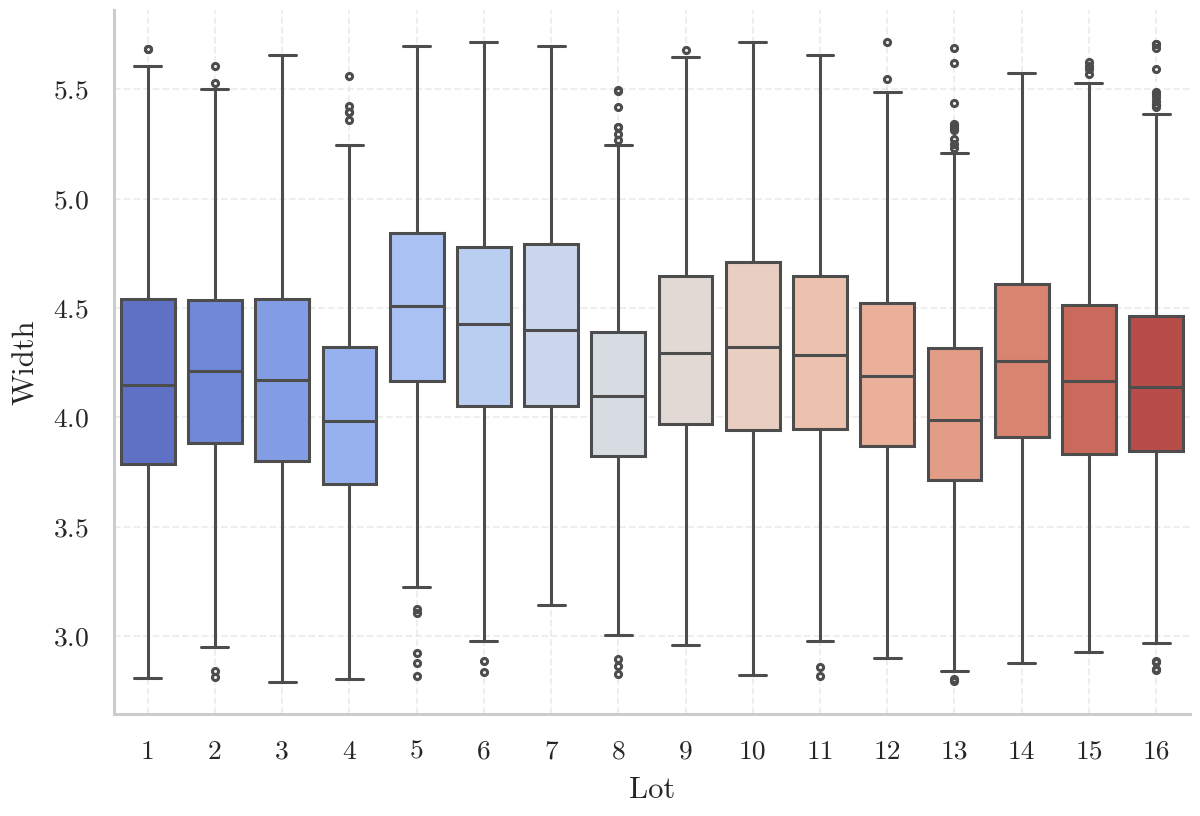

### `self_contained_boxplot_area.pdf`

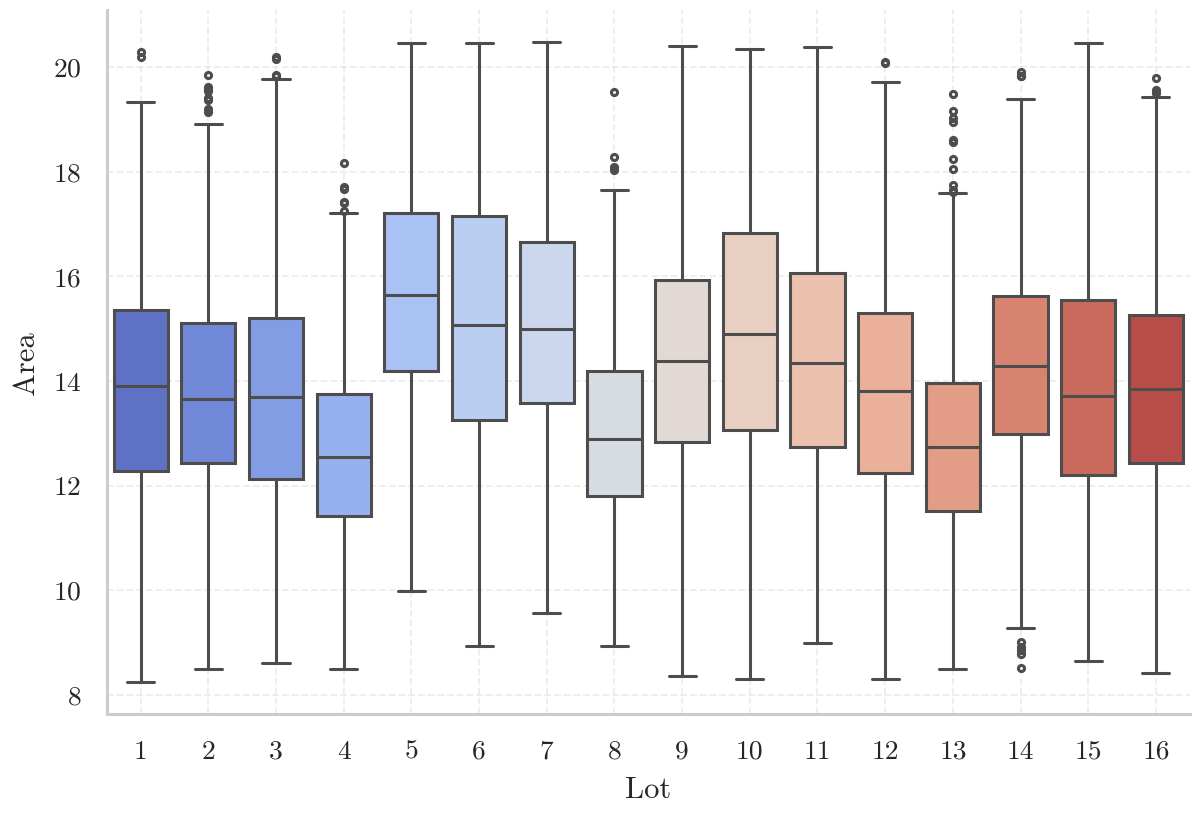

### `self_contained_boxplot_perimeter.pdf`

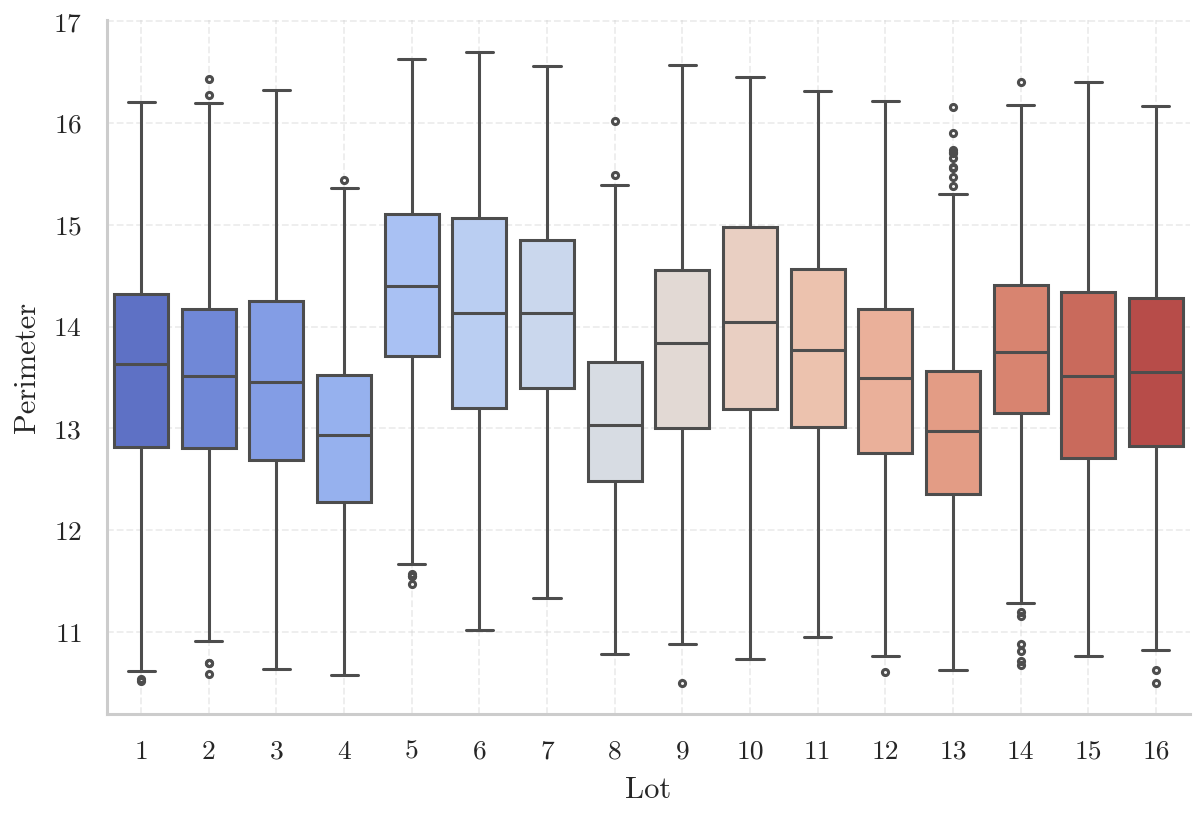

In [6]:
def plot_boxplots(df: pd.DataFrame) -> None:
    for feature in CONFIG.morphometric_features:
        fig, ax = plt.subplots(figsize=article_figsize(0.68))
        sns.boxplot(
            data=df,
            x=CONFIG.group,
            y=feature,
            hue=CONFIG.group,
            palette="coolwarm",
            dodge=False,
            linewidth=1,
            fliersize=2,
            ax=ax,
        )
        legend = ax.get_legend()
        if legend is not None:
            legend.remove()
        ax.set_xlabel("Lot")
        ax.set_ylabel(FEATURE_LABELS[feature])
        ax.tick_params(axis="x", rotation=0)
        style_axis(ax)
        save_figure(fig, f"self_contained_boxplot_{FEATURE_LABELS[feature].lower()}.pdf")


plot_boxplots(analysis_df)
show_figure_series([
    "self_contained_boxplot_length.pdf",
    "self_contained_boxplot_width.pdf",
    "self_contained_boxplot_area.pdf",
    "self_contained_boxplot_perimeter.pdf",
], width=820)

## 6. Principal Component Analysis

In [7]:
def run_pca(df: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame, PCA]:
    scaled = StandardScaler().fit_transform(df[list(CONFIG.morphometric_features)])
    pca = PCA(n_components=2, random_state=CONFIG.random_state)
    pcs = pca.fit_transform(scaled)

    scores = pd.DataFrame(pcs, columns=["PC1", "PC2"], index=df.index)
    scores[CONFIG.group] = df[CONFIG.group]

    loading_scale = 3.0
    loadings = pd.DataFrame(
        {
            "Feature": [FEATURE_LABELS[feature] for feature in CONFIG.morphometric_features],
            "PC1": pca.components_[0] * loading_scale,
            "PC2": pca.components_[1] * loading_scale,
            "explained_variance_ratio_PC1": pca.explained_variance_ratio_[0],
            "explained_variance_ratio_PC2": pca.explained_variance_ratio_[1],
        }
    )
    return scores, loadings, pca


def plot_pca_biplot(scores: pd.DataFrame, loadings: pd.DataFrame, pca: PCA) -> None:
    fig, ax = plt.subplots(figsize=article_figsize(0.76))
    lots = scores[CONFIG.group].astype("category")
    palette = dict(zip(lots.cat.categories, sns.color_palette("colorblind", lots.nunique())))

    for lot in lots.cat.categories:
        subset = scores[scores[CONFIG.group] == lot]
        ax.scatter(
            subset["PC1"],
            subset["PC2"],
            label=f"Lot {lot}",
            s=14,
            alpha=0.52,
            edgecolor="white",
            linewidth=0.2,
            color=palette[lot],
            rasterized=True,
        )

    label_offsets = {
        "Length": (0.26, 0.22),
        "Width": (0.26, -0.30),
        "Area": (0.42, 0.52),
        "Perimeter": (0.42, -0.56),
    }
    for row in loadings.itertuples(index=False):
        ax.arrow(0, 0, row.PC1, row.PC2, head_width=0.12, width=0.012, length_includes_head=True, color="#2f2f2f", alpha=0.95, zorder=4)
        dx, dy = label_offsets.get(row.Feature, (0.20, 0.18))
        ax.annotate(
            f"{row.Feature}\nPC1={row.PC1:.2f}, PC2={row.PC2:.2f}",
            xy=(row.PC1, row.PC2),
            xytext=(row.PC1 + dx, row.PC2 + dy),
            textcoords="data",
            fontsize=7.4,
            weight="semibold",
            ha="left",
            va="center",
            bbox={"boxstyle": "round,pad=0.18", "facecolor": "white", "edgecolor": "0.72", "alpha": 0.90},
            arrowprops={"arrowstyle": "-", "color": "0.35", "lw": 0.6, "shrinkA": 0, "shrinkB": 5},
            zorder=5,
        )

    ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}% variance explained)")
    ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}% variance explained)")
    ax.axhline(0, color="0.45", linewidth=0.8, linestyle="--", zorder=1)
    ax.axvline(0, color="0.45", linewidth=0.8, linestyle="--", zorder=1)
    ax.margins(x=0.14, y=0.16)
    style_axis(ax)
    fig.subplots_adjust(right=0.78)
    ax.legend(title="Lots", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=6.3, title_fontsize=7.2, labelspacing=0.25, handletextpad=0.35, borderaxespad=0.2)
    save_figure(fig, "self_contained_pca_biplot.pdf")


pca_scores, pca_loadings, pca_model = run_pca(analysis_df)
pca_loadings.to_csv(OUTPUTS_DIR / "self_contained_pca_loadings.csv", index=False)
plot_pca_biplot(pca_scores, pca_loadings, pca_model)
pca_loadings.round(3)

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


,Feature,PC1,PC2,explained_variance_ratio_PC1,explained_variance_ratio_PC2
0,Length,1.210,-2.115,0.73,0.259
1,Width,1.202,2.128,0.73,0.259
2,Area,1.742,0.005,0.73,0.259
3,Perimeter,1.748,-0.004,0.73,0.259


### `self_contained_pca_biplot.pdf`

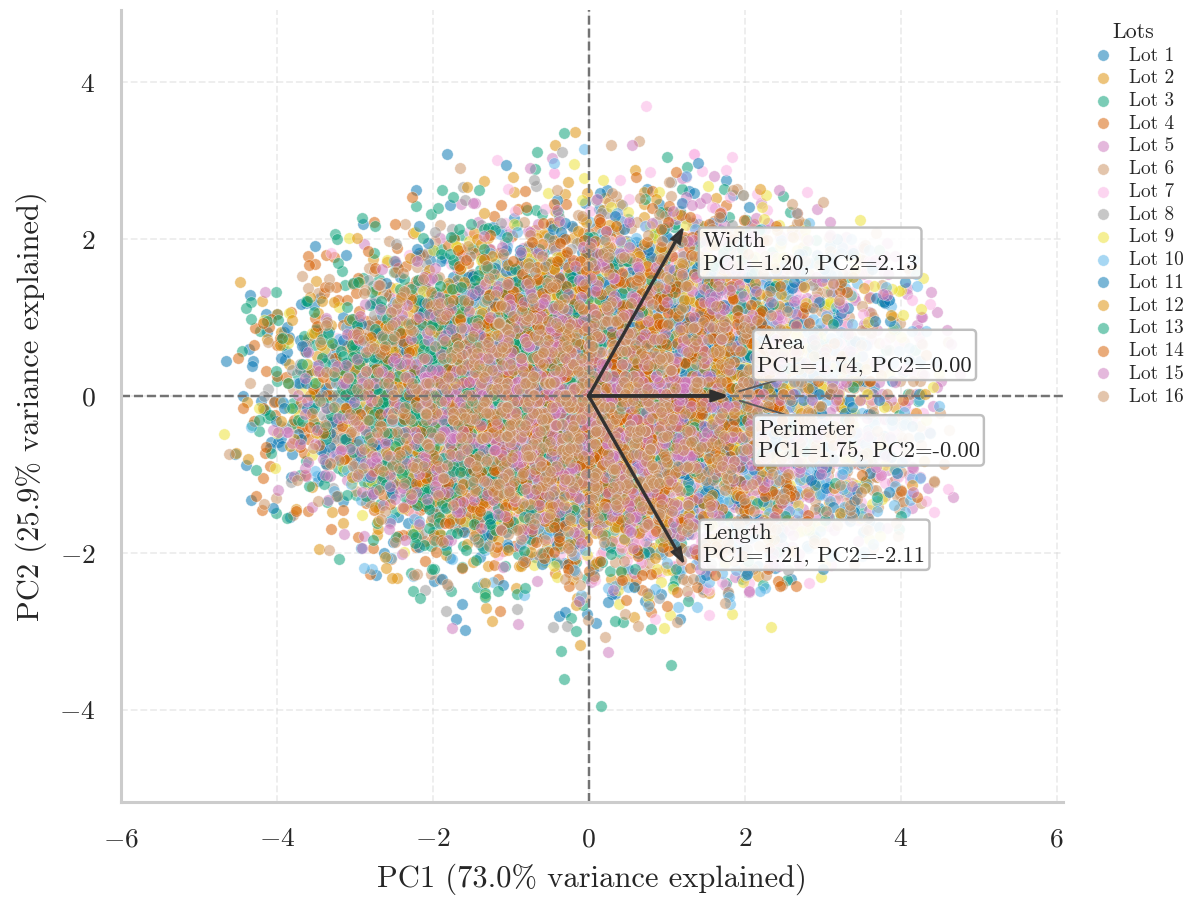

In [8]:
show_figure("self_contained_pca_biplot.pdf", width=900)

## 7. MANOVA by Lot

In [9]:
def run_manova(df: pd.DataFrame) -> pd.DataFrame:
    formula = 'Q("length_mm") + Q("width_mm") + Q("area_mm2") + Q("perimeter_mm") ~ lot'
    manova = MANOVA.from_formula(formula, data=df)
    return pd.DataFrame(manova.mv_test().results[CONFIG.group]["stat"]).round(4)


def plot_manova_table(manova_df: pd.DataFrame) -> None:
    fig, ax = plt.subplots(figsize=(10.5, 2.6))
    ax.axis("off")
    table_plot = ax.table(
        cellText=manova_df.values,
        colLabels=manova_df.columns,
        rowLabels=manova_df.index,
        loc="center",
    )
    table_plot.auto_set_font_size(False)
    table_plot.set_fontsize(10)
    table_plot.scale(1.15, 1.45)
    for (row, col), cell in table_plot.get_celld().items():
        cell.set_edgecolor("#d6dbe0")
        if row == 0 or col == -1:
            cell.set_facecolor("#edf2f7")
            cell.set_text_props(weight="bold")
    ax.set_title("MANOVA: effect of locality on seed morphometric traits", fontsize=10, fontweight="bold", pad=10)
    save_figure(fig, "self_contained_manova_locality.pdf")


manova_results = run_manova(analysis_df)
manova_results.to_csv(OUTPUTS_DIR / "self_contained_manova_results.csv")
plot_manova_table(manova_results)
manova_results

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


,Value,Num DF,Den DF,F Value,Pr > F
Wilks' lambda,0.840708,60,60483.009117,45.818786,0.0
Pillai's trace,0.163543,60.0,61988.0,44.041184,0.0
Hotelling-Lawley trace,0.184452,60,48016.492143,47.627568,0.0
Roy's greatest root,0.153417,15,15497,158.499796,0.0


### `self_contained_manova_locality.pdf`

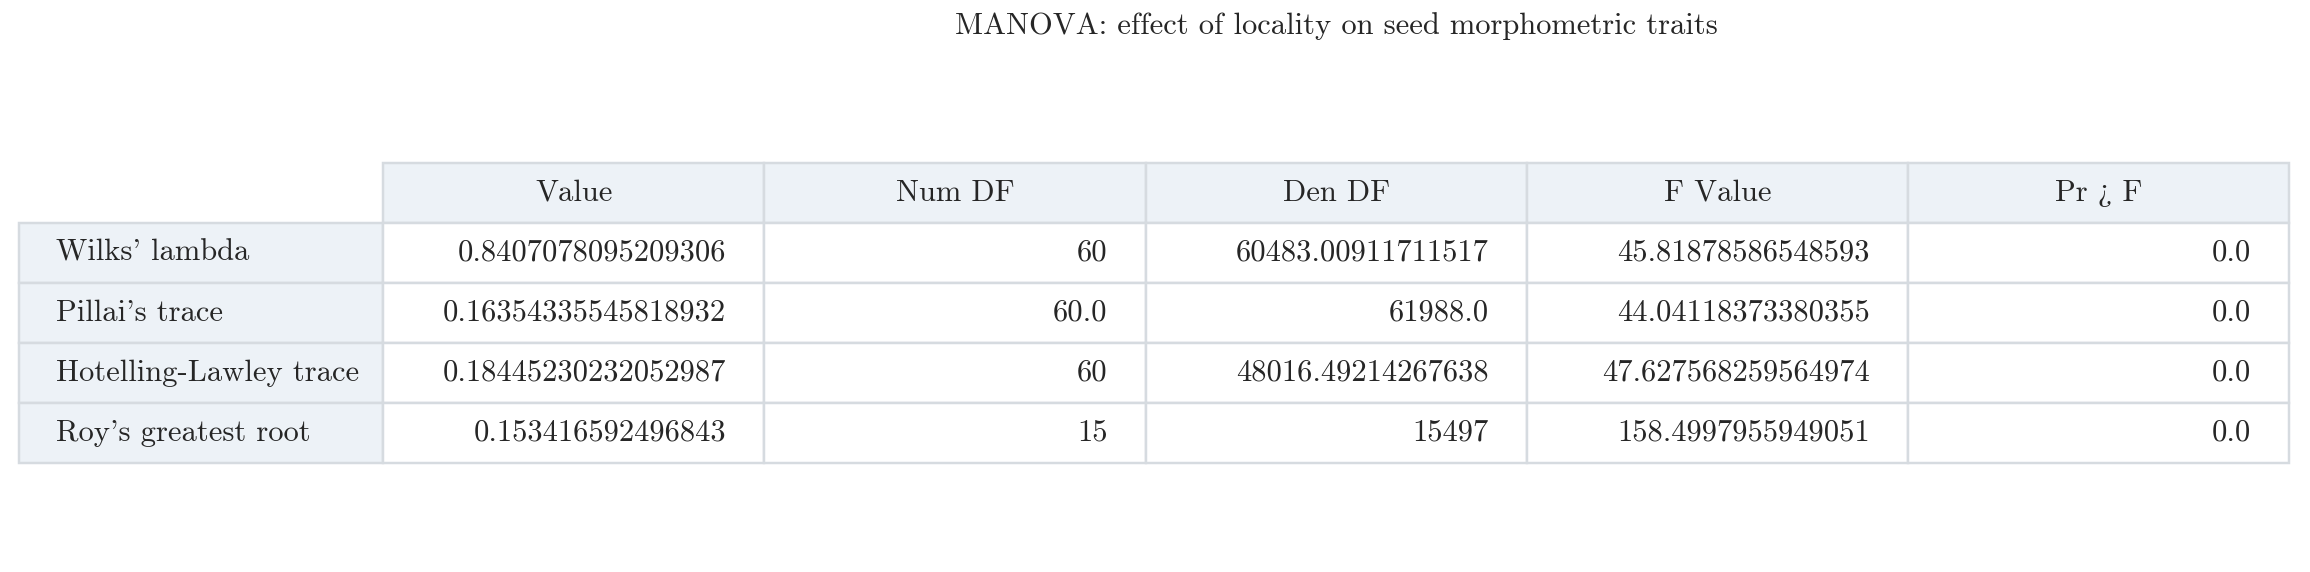

In [10]:
show_figure("self_contained_manova_locality.pdf", width=900)

## 8. Random Forest and Linear SVM Classification

In [11]:
def make_one_hot_encoder() -> OneHotEncoder:
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


def make_linear_svm() -> CalibratedClassifierCV:
    linear_svc = LinearSVC(
        class_weight="balanced",
        random_state=CONFIG.random_state,
        dual=False,
        max_iter=10000,
    )
    try:
        return CalibratedClassifierCV(estimator=linear_svc, cv=3)
    except TypeError:
        return CalibratedClassifierCV(base_estimator=linear_svc, cv=3)


def make_preprocessor() -> ColumnTransformer:
    return ColumnTransformer(
        [
            ("numeric", StandardScaler(), CONFIG.model_numeric_features),
            ("lot", make_one_hot_encoder(), [CONFIG.group]),
        ]
    )


def find_best_threshold(y_true: pd.Series, probabilities: np.ndarray) -> tuple[float, float]:
    thresholds = np.linspace(0.05, 0.95, 181)
    scores = [f1_score(y_true, probabilities >= threshold, average="macro") for threshold in thresholds]
    best_index = int(np.argmax(scores))
    return float(thresholds[best_index]), float(scores[best_index])


def evaluate_predictions(y_true: pd.Series, probabilities: np.ndarray, threshold: float) -> dict:
    predictions = (probabilities >= threshold).astype(int)
    cm = confusion_matrix(y_true, predictions, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    return {
        "threshold": threshold,
        "balanced_accuracy": balanced_accuracy_score(y_true, predictions),
        "f1_macro": f1_score(y_true, predictions, average="macro"),
        "f1_germinated": f1_score(y_true, predictions, pos_label=1),
        "recall_no_germination": recall_score(y_true, predictions, pos_label=0),
        "recall_germination": recall_score(y_true, predictions, pos_label=1),
        "precision_no_germination": precision_score(y_true, predictions, pos_label=0, zero_division=0),
        "precision_germination": precision_score(y_true, predictions, pos_label=1, zero_division=0),
        "roc_auc": roc_auc_score(y_true, probabilities),
        "pr_auc": average_precision_score(y_true, probabilities),
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp,
        "confusion_matrix": cm,
        "predictions": predictions,
        "probabilities": probabilities,
    }


X = analysis_df[CONFIG.model_features]
y = analysis_df[CONFIG.target].astype(int)

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=CONFIG.random_state,
    stratify=y,
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val,
    y_train_val,
    test_size=0.25,
    random_state=CONFIG.random_state,
    stratify=y_train_val,
)

models = {
    "Random Forest": RandomForestClassifier(
        n_estimators=600,
        max_features="sqrt",
        min_samples_leaf=4,
        class_weight="balanced_subsample",
        random_state=CONFIG.random_state,
        n_jobs=-1,
    ),
    "Linear SVM": make_linear_svm(),
}

model_results = {}
summary_rows = []
classification_rows = []

for model_name, estimator in models.items():
    pipeline = Pipeline([("preprocessor", make_preprocessor()), ("model", estimator)])
    pipeline.fit(X_train, y_train)

    val_probabilities = pipeline.predict_proba(X_val)[:, 1]
    threshold, validation_f1_macro = find_best_threshold(y_val, val_probabilities)

    test_probabilities = pipeline.predict_proba(X_test)[:, 1]
    metrics = evaluate_predictions(y_test, test_probabilities, threshold)
    model_results[model_name] = {"pipeline": pipeline, "validation_f1_macro": validation_f1_macro, **metrics}

    summary_rows.append({
        "model": model_name,
        "threshold": threshold,
        "validation_f1_macro": validation_f1_macro,
        "balanced_accuracy": metrics["balanced_accuracy"],
        "f1_macro": metrics["f1_macro"],
        "f1_germinated": metrics["f1_germinated"],
        "recall_no_germination": metrics["recall_no_germination"],
        "recall_germination": metrics["recall_germination"],
        "precision_no_germination": metrics["precision_no_germination"],
        "precision_germination": metrics["precision_germination"],
        "roc_auc": metrics["roc_auc"],
        "pr_auc": metrics["pr_auc"],
        "tn": metrics["tn"],
        "fp": metrics["fp"],
        "fn": metrics["fn"],
        "tp": metrics["tp"],
    })

    report = classification_report(
        y_test,
        metrics["predictions"],
        target_names=list(CONFIG.class_labels),
        output_dict=True,
        zero_division=0,
    )
    for label, values in report.items():
        if isinstance(values, dict):
            classification_rows.append({"model": model_name, "class": label, **values})

model_summary = pd.DataFrame(summary_rows).sort_values("f1_macro", ascending=False)
classification_report_df = pd.DataFrame(classification_rows)
model_summary.to_csv(OUTPUTS_DIR / "self_contained_model_summary.csv", index=False)
classification_report_df.to_csv(OUTPUTS_DIR / "self_contained_classification_report.csv", index=False)
model_summary.round(3)

,model,threshold,validation_f1_macro,balanced_accuracy,f1_macro,f1_germinated,recall_no_germination,recall_germination,precision_no_germination,precision_germination,roc_auc,pr_auc,tn,fp,fn,tp
1,Linear SVM,0.485,0.749,0.730,0.731,0.660,0.809,0.652,0.796,0.669,0.805,0.671,2361,559,604,1130
0,Random Forest,0.460,0.728,0.736,0.724,0.676,0.724,0.749,0.829,0.617,0.796,0.648,2113,807,436,1298


## 9. Classification Figures

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


### `self_contained_precision_recall_curve.pdf`

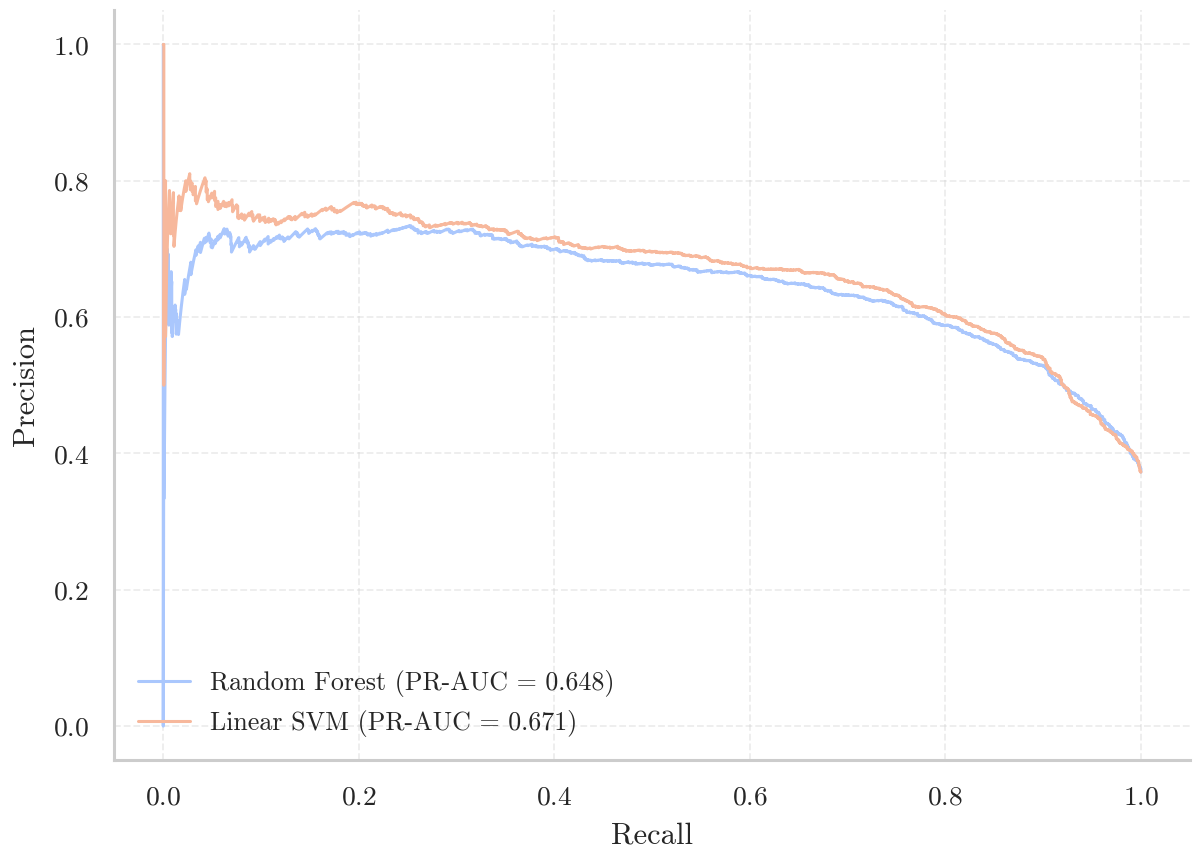

### `self_contained_roc_curve.pdf`

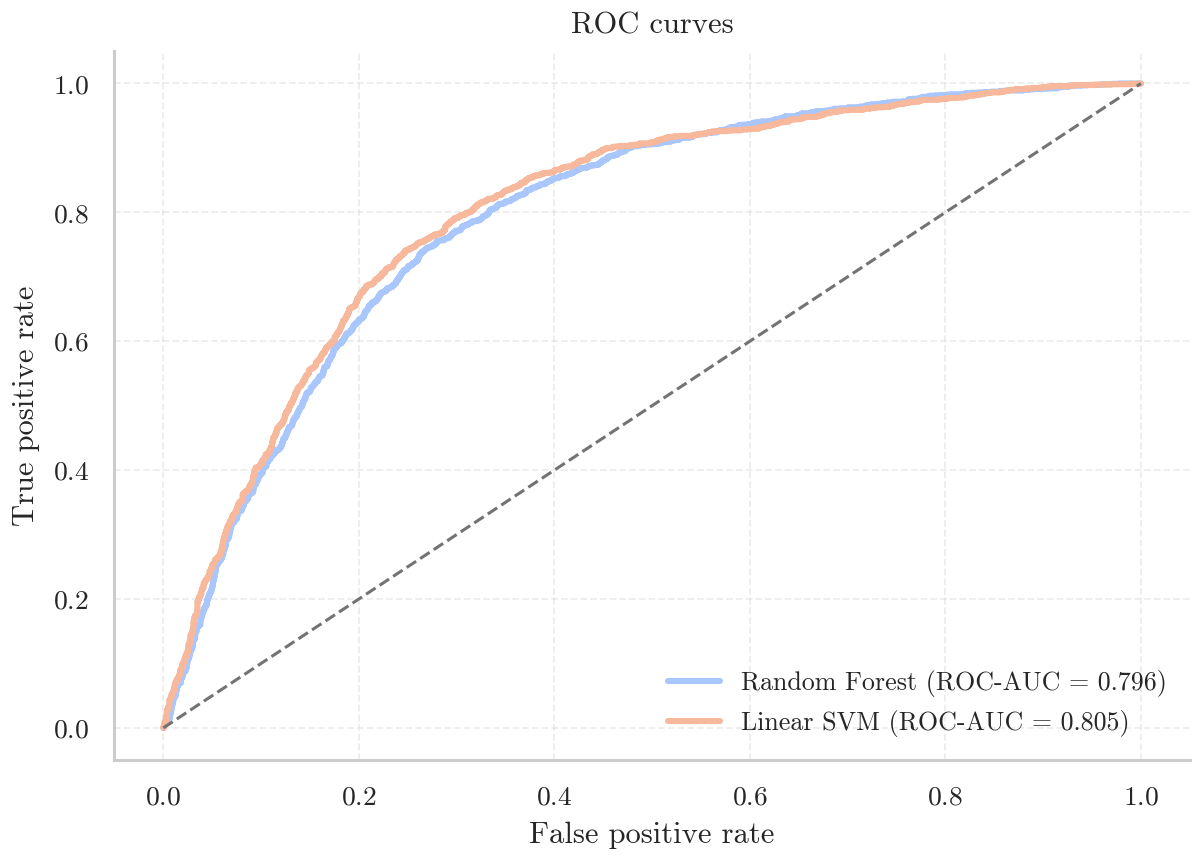

### `self_contained_confusion_matrix_counts_linear_svm.pdf`

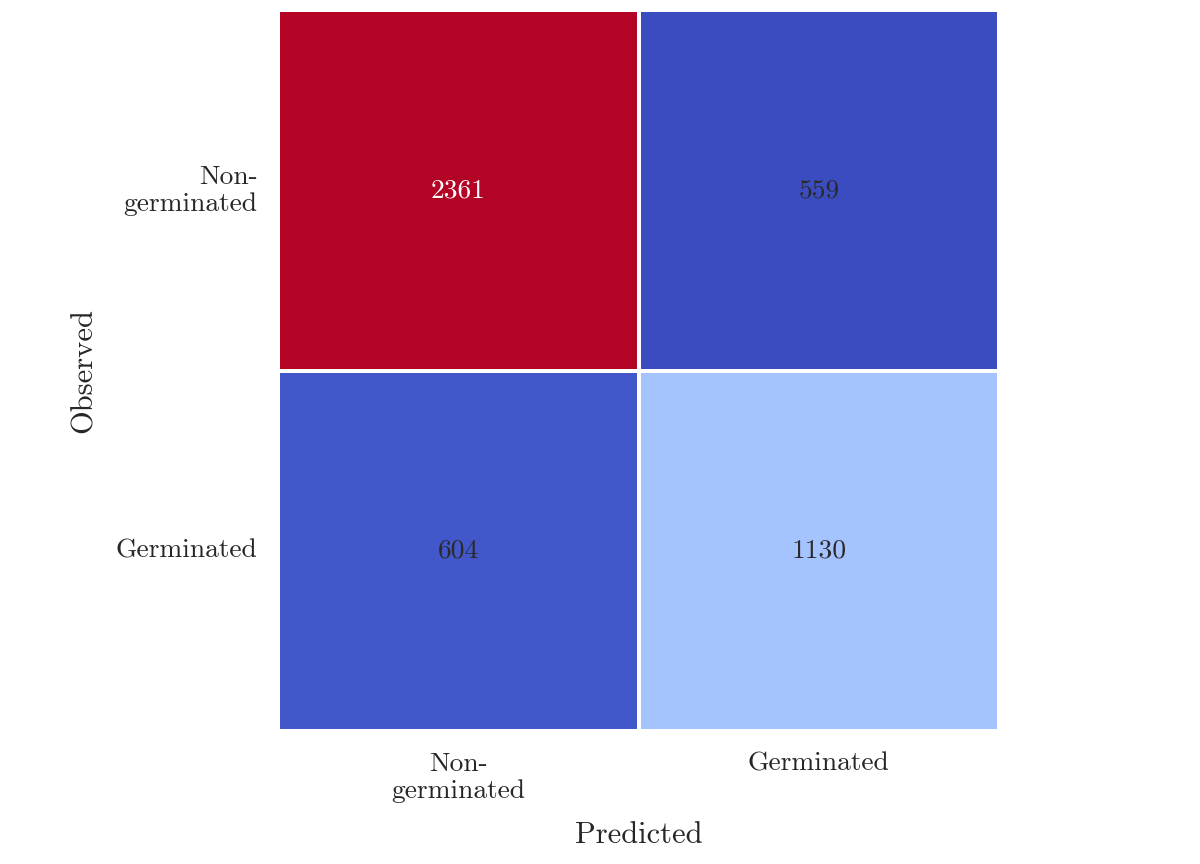

### `self_contained_confusion_matrix_percent_linear_svm.pdf`

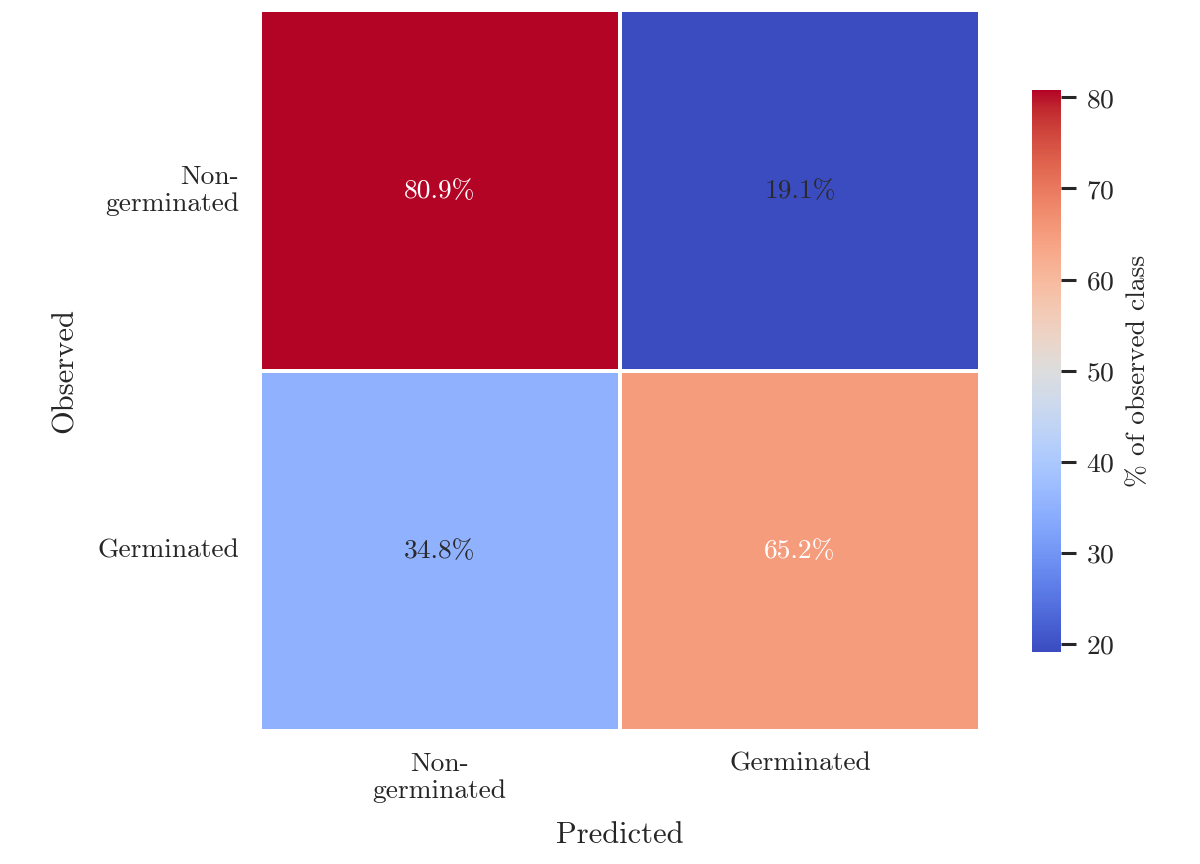

### `self_contained_confusion_matrix_counts_random_forest.pdf`

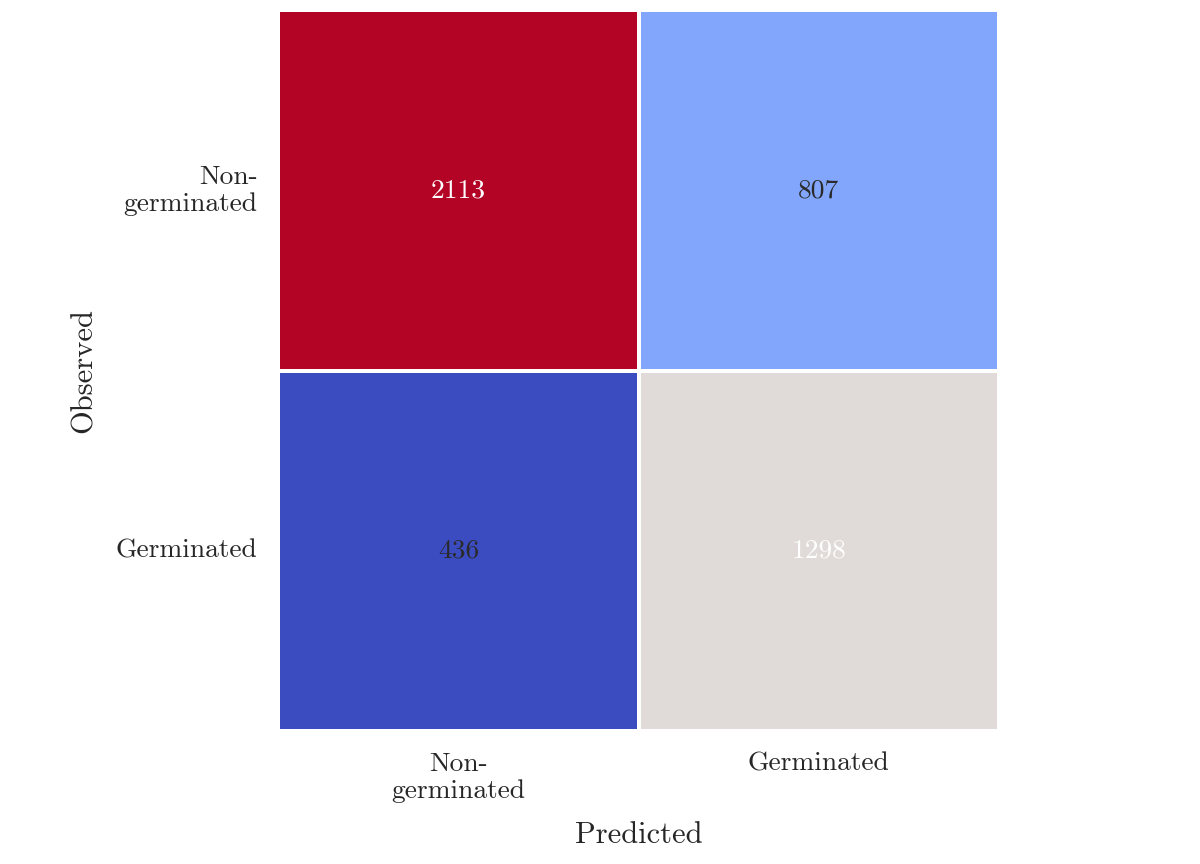

### `self_contained_confusion_matrix_percent_random_forest.pdf`

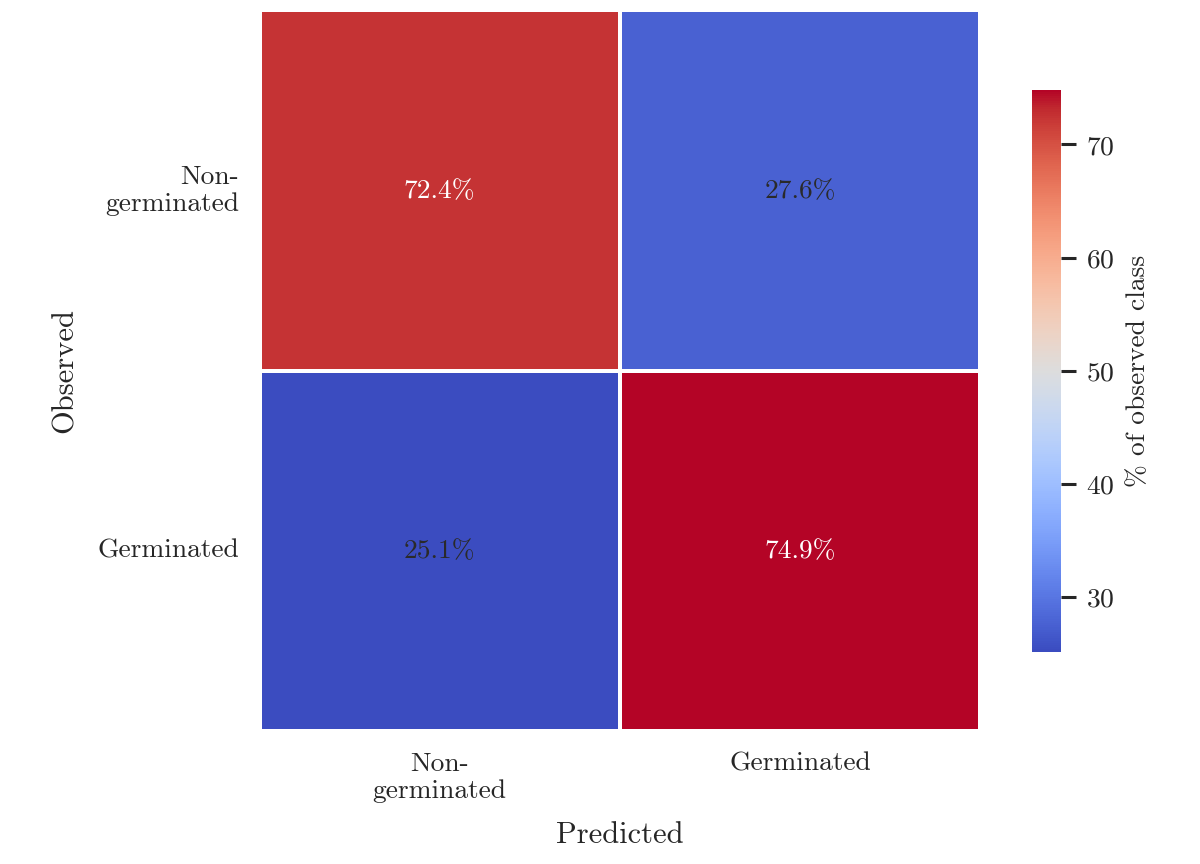

In [12]:
def normalize_confusion_matrix(cm: np.ndarray) -> np.ndarray:
    row_totals = cm.sum(axis=1, keepdims=True)
    return np.divide(cm, row_totals, out=np.zeros_like(cm, dtype=float), where=row_totals != 0) * 100


def plot_precision_recall_curves() -> None:
    fig, ax = plt.subplots(figsize=article_figsize(0.72))
    selected_models = ["Random Forest", "Linear SVM"]
    colors = sns.color_palette("coolwarm", len(selected_models))
    for index, model_name in enumerate(selected_models):
        result = model_results[model_name]
        precision, recall, _ = precision_recall_curve(y_test, result["probabilities"])
        ax.plot(recall, precision, linewidth=1, color=colors[index], label=f"{model_name} (PR-AUC = {result['pr_auc']:.3f})")
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.legend(loc="lower left", fontsize=8.5)
    style_axis(ax)
    save_figure(fig, "self_contained_precision_recall_curve.pdf")


def plot_roc_curves() -> None:
    fig, ax = plt.subplots(figsize=article_figsize(0.72))
    selected_models = ["Random Forest", "Linear SVM"]
    colors = sns.color_palette("coolwarm", len(selected_models))
    for index, model_name in enumerate(selected_models):
        result = model_results[model_name]
        fpr, tpr, _ = roc_curve(y_test, result["probabilities"])
        ax.plot(fpr, tpr, linewidth=2, color=colors[index], label=f"{model_name} (ROC-AUC = {result['roc_auc']:.3f})")
    ax.plot([0, 1], [0, 1], linestyle="--", color="0.45", linewidth=1)
    ax.set_xlabel("False positive rate")
    ax.set_ylabel("True positive rate")
    ax.set_title("ROC curves")
    ax.legend(loc="lower right", fontsize=8.5)
    style_axis(ax)
    save_figure(fig, "self_contained_roc_curve.pdf")


def plot_confusion_matrix_heatmap(model_name: str, normalize: bool = False) -> None:
    cm = model_results[model_name]["confusion_matrix"]
    values = normalize_confusion_matrix(cm) if normalize else cm
    axis_labels = ["Non-\ngerminated", "Germinated"]
    fig, ax = plt.subplots(figsize=article_figsize(0.72))
    sns.heatmap(
        values,
        annot=False,
        cmap="coolwarm",
        cbar=normalize,
        cbar_kws={"shrink": 0.78, "label": "% of observed class"} if normalize else None,
        square=True,
        linewidths=0.7,
        linecolor="white",
        xticklabels=axis_labels,
        yticklabels=axis_labels,
        ax=ax,
    )
    text_threshold = np.nanmax(values) * 0.55 if np.nanmax(values) > 0 else 0
    for row_index in range(values.shape[0]):
        for col_index in range(values.shape[1]):
            value = values[row_index, col_index]
            label = f"{value:.1f}%" if normalize else f"{int(value)}"
            color = "white" if value >= text_threshold else "#2a2a2a"
            ax.text(col_index + 0.5, row_index + 0.5, label, ha="center", va="center", fontsize=9, fontweight="bold", color=color)
    ax.set_xlabel("Predicted", fontsize=10, labelpad=6)
    ax.set_ylabel("Observed", fontsize=10, labelpad=6)
    ax.tick_params(axis="x", labelrotation=0, labelsize=9, pad=2)
    ax.tick_params(axis="y", labelrotation=0, labelsize=9, pad=2)
    if normalize and ax.collections[0].colorbar is not None:
        ax.collections[0].colorbar.ax.tick_params(labelsize=9)
        ax.collections[0].colorbar.set_label("% of observed class", fontsize=9)
    suffix = "percent" if normalize else "counts"
    model_slug = model_name.lower().replace(" ", "_")
    save_figure(fig, f"self_contained_confusion_matrix_{suffix}_{model_slug}.pdf")


plot_precision_recall_curves()
plot_roc_curves()
for name in model_summary["model"]:
    plot_confusion_matrix_heatmap(name, normalize=False)
    plot_confusion_matrix_heatmap(name, normalize=True)

show_figure_series([
    "self_contained_precision_recall_curve.pdf",
    "self_contained_roc_curve.pdf",
    "self_contained_confusion_matrix_counts_linear_svm.pdf",
    "self_contained_confusion_matrix_percent_linear_svm.pdf",
    "self_contained_confusion_matrix_counts_random_forest.pdf",
    "self_contained_confusion_matrix_percent_random_forest.pdf",
], width=820)

## 10. Reproducibility Metadata

In [13]:
pd.DataFrame(
    {
        "item": ["python", "platform", "pandas", "numpy", "scikit-learn", "seaborn"],
        "version": [
            sys.version.split()[0],
            platform.platform(),
            pd.__version__,
            np.__version__,
            __import__("sklearn").__version__,
            sns.__version__,
        ],
    }
)

,item,version
0,python,3.11.7
1,platform,macOS-26.3.1-arm64-arm-64bit
2,pandas,3.0.2
3,numpy,1.26.4
4,scikit-learn,1.8.0
5,seaborn,0.13.2
